# **Milestone 2: Early Analysis & Insights**
# **Trajectory Types of Childcare Cost Growth 2008-2018 and Who Experiences Them**



A1 Team 6: Yuanhao Li

## Motivation and Executive Summary

Childcare costs have shown strong time trends and clear differences across age groups in our Milestone 1 exploration. Because affordability pressures often build gradually over multiple years, focusing on single year snapshots may miss important dynamics. In this milestone I treat each county's multi year series as a cost trajectory and ask whether a small number of common trajectory patterns exist from 2008 to 2018.

In this notebook, I first define which counties have enough time coverage to support a trajectory analysis, then compare different ways of representing trajectories. I apply two unsupervised approaches to discover recurring patterns and interpret who experiences them by linking the resulting trajectory types to county socioeconomic context and state differences.


## Specific Question and What Changed from M1

For counties with sufficient data coverage, do childcare costs from 2008 to 2018 follow a small number of common trajectory patterns, such as steady growth, sharp increases, sudden jumps or relative stability?

In M2, I make the question operational by defining sufficient time coverage and by representing each county as a standardized trajectory rather than comparing single year levels. This shift is motivated by the strong time trends observed in M1 and by the need to avoid misleading conclusions from counties with sparse reporting.


## 1.Data importing & Instructure

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [175]:
CHILD_URL = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/childcare_costs.csv"
COUNTY_URL = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/counties.csv"

child = pd.read_csv(CHILD_URL)
counties = pd.read_csv(COUNTY_URL)

print("child shape:", child.shape)
print("counties shape:", counties.shape)

child shape: (34567, 61)
counties shape: (3144, 4)


In [176]:
child.head(3)

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96


In [177]:
counties.head(3)

,county_fips_code,county_name,state_name,state_abbreviation
0,1001,Autauga County,Alabama,AL
1,1003,Baldwin County,Alabama,AL
2,1005,Barbour County,Alabama,AL


The childcare_costs table is long format with one row per county year and multiple cost variables by age group. The counties table provides county and state context and socioeconomic fields. I merge them to support interpretation of trajectory types.


In [178]:
COL_FIPS = "county_fips_code"
COL_YEAR = "study_year"

COST_INFANT = "mc_infant"
COST_TODDLER = "mc_toddler"
COST_PRESCHOOL = "mc_preschool"

STATE_ABBR = "state_abbreviation"
COUNTY_NAME = "county_name"

SOCIO_COLS = ["mhi_2018", "unr_20to64", "flfpr_20to64"]
SOCIO_COLS = [c for c in SOCIO_COLS if c in counties.columns]

df = child.merge(counties, on=COL_FIPS, how="left")
df[[COL_FIPS, COL_YEAR, COST_INFANT, STATE_ABBR, COUNTY_NAME] + SOCIO_COLS].head(3)

,county_fips_code,study_year,mc_infant,state_abbreviation,county_name
0,1001,2008,104.95,AL,Autauga County
1,1001,2009,105.11,AL,Autauga County
2,1001,2010,105.28,AL,Autauga County


In [179]:
print("Years:", df[COL_YEAR].min(), "to", df[COL_YEAR].max())
print("Unique counties:", df[COL_FIPS].nunique())
print("Infant cost missing rate:", round(df[COST_INFANT].isna().mean(), 3))

Years: 2008 to 2018
Unique counties: 3144
Infant cost missing rate: 0.317


## 2.Coverage analysis and threshold definition


Trajectory analysis needs repeated observations across years. Here I look at how many years each county has infant cost data and pick a simple coverage threshold for the main analysis.


In [180]:
years_all = sorted(df[COL_YEAR].dropna().unique())
min_year, max_year = int(min(years_all)), int(max(years_all))
n_total_years = (max_year - min_year + 1)

cov = (
    df.dropna(subset=[COST_INFANT])
      .groupby(COL_FIPS)[COL_YEAR]
      .nunique()
      .rename("n_years_infant")
      .to_frame()
)
cov["share_years_infant"] = cov["n_years_infant"] / n_total_years
cov.describe()

,n_years_infant,share_years_infant
count,2904.000000,2904.000000
mean,8.124311,0.738574
std,3.805381,0.345944
min,1.000000,0.090909
25%,5.000000,0.454545
50%,10.000000,0.909091
75%,11.000000,1.000000
max,11.000000,1.000000


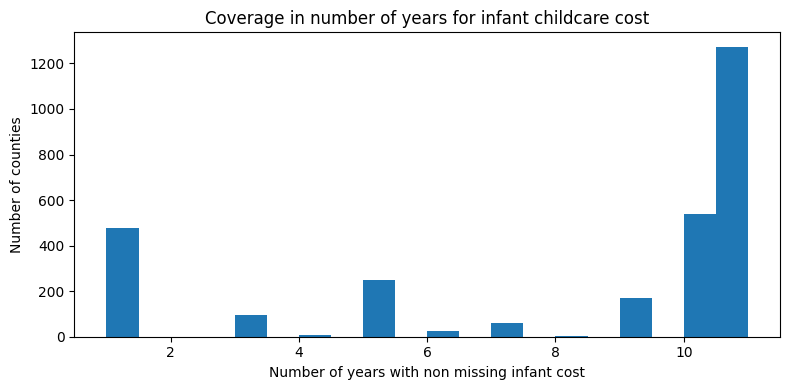

In [181]:
plt.figure(figsize=(8,4))
plt.hist(cov["n_years_infant"], bins=20)
plt.title("Coverage in number of years for infant childcare cost")
plt.xlabel("Number of years with non missing infant cost")
plt.ylabel("Number of counties")
plt.tight_layout()
plt.show()

Coverage is highly uneven across counties with a large group having near complete data from 2008 to 2018 and a nontrivial number of counties having only a few years of observations. This supports the need to define a coverage threshold before constructing multi year trajectories.


In [182]:
THRESH_MAIN = 9
ids_main = cov.index[cov["n_years_infant"] >= THRESH_MAIN]
print("Counties meeting threshold:", len(ids_main))

Counties meeting threshold: 1984


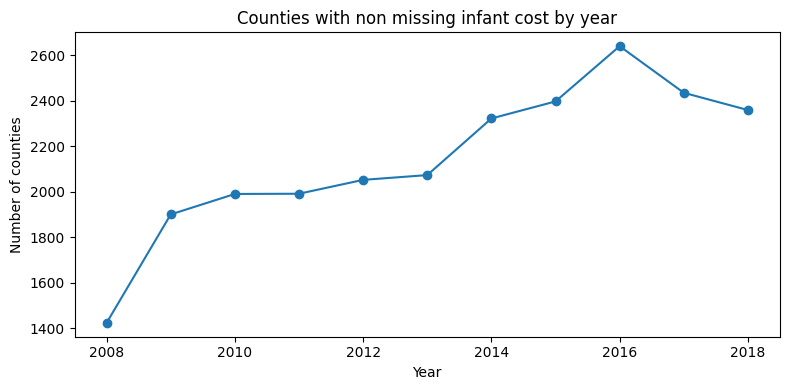

In [183]:
year_avail = (df.dropna(subset=[COST_INFANT]).groupby(COL_YEAR)[COL_FIPS].nunique().sort_index())

plt.figure(figsize=(8,4))
plt.plot(year_avail.index, year_avail.values, marker="o")
plt.title("Counties with non missing infant cost by year")
plt.xlabel("Year")
plt.ylabel("Number of counties")
plt.tight_layout()
plt.show()

The number of reporting counties changes across years, so sparse coverage could distort trajectory shape if including counties with too many gaps.


## 3.Build trajectories and quick EDA

I pivot the infant cost series into a county by year matrix and use simple interpolation to fill internal gaps. To focus on trajectory shape rather than level, I standardize within county.


In [184]:
traj_raw = df.pivot_table(index=COL_FIPS, columns=COL_YEAR, values=COST_INFANT, aggfunc="mean")
traj_raw = traj_raw.loc[:, [y for y in traj_raw.columns if 2008 <= int(y) <= 2018]]
traj_raw = traj_raw.loc[ids_main].copy()

traj_fill = traj_raw.interpolate(axis=1, limit_direction="both")
traj_fill = traj_fill.dropna(axis=0, how="any")

print("Trajectory matrix shape:", traj_fill.shape)

Trajectory matrix shape: (1984, 11)


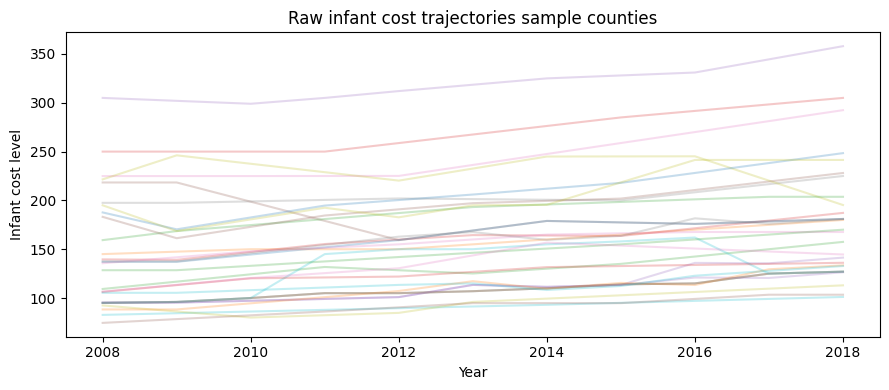

In [185]:
np.random.seed(0)
sample_ids = np.random.choice(traj_fill.index, size=min(30, len(traj_fill)), replace=False)

plt.figure(figsize=(9,4))
for cid in sample_ids:
    plt.plot(traj_fill.columns, traj_fill.loc[cid].values, alpha=0.25)
plt.title("Raw infant cost trajectories sample counties")
plt.xlabel("Year")
plt.ylabel("Infant cost level")
plt.tight_layout()
plt.show()

Most counties show a broadly increasing trajectory over time but there is noticeable variation in slope and shape across counties. Some trajectories rise smoothly while others exhibit sharper changes or temporary reversals which suggests that treating counties as following identical trends would miss meaningful heterogeneity.


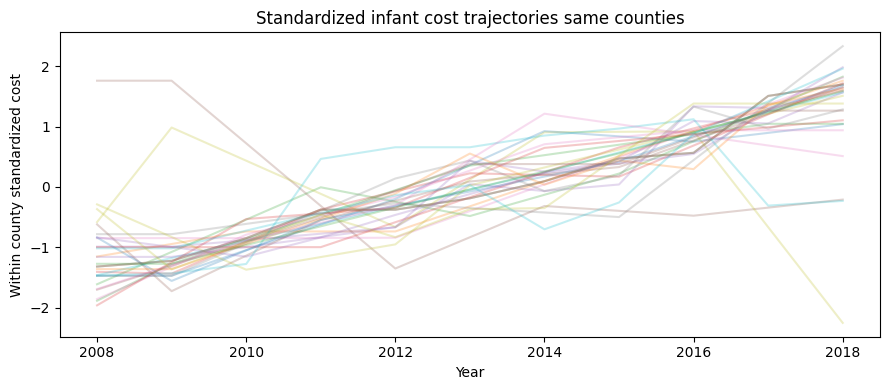

Standardized matrix shape: (1984, 11)


In [186]:
traj_z = traj_fill.sub(traj_fill.mean(axis=1), axis=0).div(traj_fill.std(axis=1).replace(0, np.nan), axis=0)
traj_z = traj_z.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

plt.figure(figsize=(9,4))
for cid in sample_ids:
    if cid in traj_z.index:
        plt.plot(traj_z.columns, traj_z.loc[cid].values, alpha=0.25)
plt.title("Standardized infant cost trajectories same counties")
plt.xlabel("Year")
plt.ylabel("Within county standardized cost")
plt.tight_layout()
plt.show()

print("Standardized matrix shape:", traj_z.shape)

Raw levels vary a lot across counties, but after standardization we can more clearly compare trajectory shapes such as steady growth versus sharper rises.


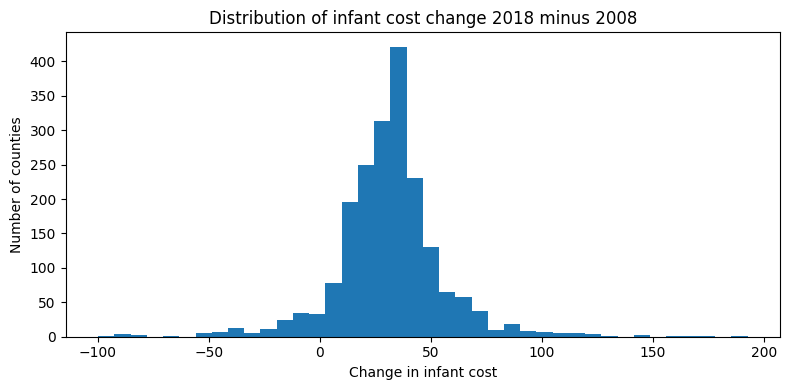

count    1984.00
mean       30.96
std        24.60
min       -99.75
25%        19.74
50%        32.00
75%        41.43
max       192.50
dtype: float64


In [195]:
delta = (traj_fill[2018] - traj_fill[2008]).dropna()

plt.figure(figsize=(8,4))
plt.hist(delta, bins=40)
plt.title("Distribution of infant cost change 2018 minus 2008")
plt.xlabel("Change in infant cost")
plt.ylabel("Number of counties")
plt.tight_layout()
plt.show()

print(delta.describe().round(2))

## 4.Method 1 KMeans clustering on standardized trajectories

I group counties with similar trajectory shapes to see whether a small set of recurring patterns exists.I use KMeans as a simple baseline because it produces interpretable clusters and allows straightforward exploration of the number of groups.


In [188]:
X = traj_z.values
years = traj_z.columns.tolist()

ks = list(range(3, 9))
inertias = []
silhs = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X, labels))

inertias, silhs

([4453.696807936361,
  3771.4273102399816,
  3305.6819412442187,
  2968.546025651074,
  2733.9882051280524,
  2543.3010836978615],
 [np.float64(0.4687009446682309),
  np.float64(0.2481427557455294),
  np.float64(0.25442031099598117),
  np.float64(0.26139493069907327),
  np.float64(0.26913816244193434),
  np.float64(0.2681262174363468)])

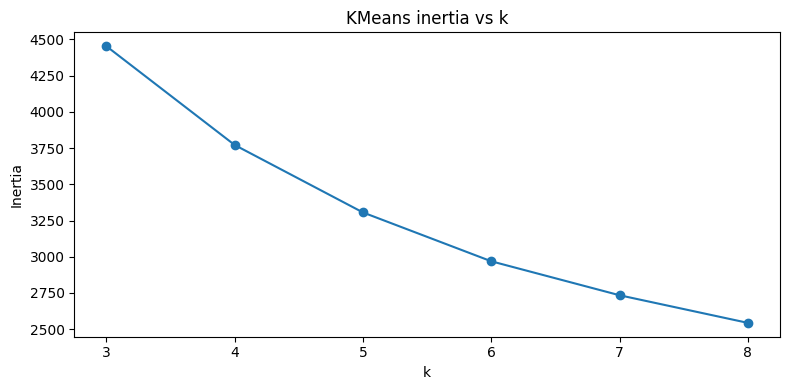

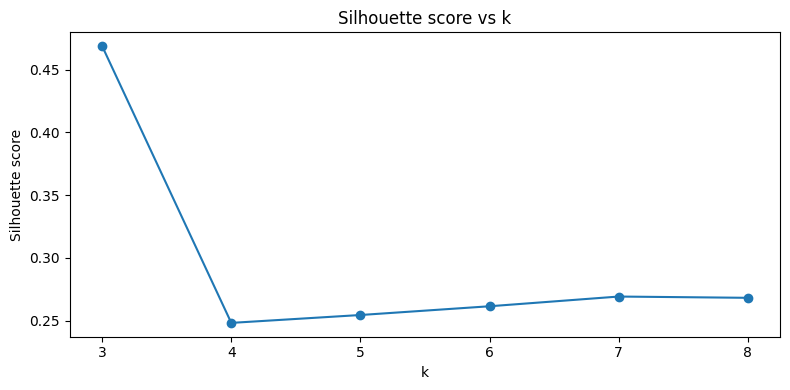

In [189]:
plt.figure(figsize=(8,4))
plt.plot(ks, inertias, marker="o")
plt.title("KMeans inertia vs k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(ks, silhs, marker="o")
plt.title("Silhouette score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

The inertia decreases smoothly as k increases, without a sharp elbow, which suggests there is no single obviously optimal number of clusters. The silhouette score is highest at k = 3 but drops substantially at k = 4 and then increases only slightly for larger k, remaining relatively low overall. This pattern suggests that while very small k values force stronger separation, larger k values mainly split existing groups rather than revealing fundamentally new structure. Based on this tradeoff, I ended up using k=4 because k=3 looked too coarse when I inspected the mean trajectories, and k>4 mainly split patterns into smaller variations without adding much interpretability.



In [190]:
# explore k and evaluate
K_FINAL = 4

km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=50)
labels = km.fit_predict(X)

clustered = pd.DataFrame({COL_FIPS: traj_z.index, "cluster": labels}).set_index(COL_FIPS)
clustered["cluster"].value_counts().sort_index()

,count
cluster,
0,76
1,215
2,1000
3,693


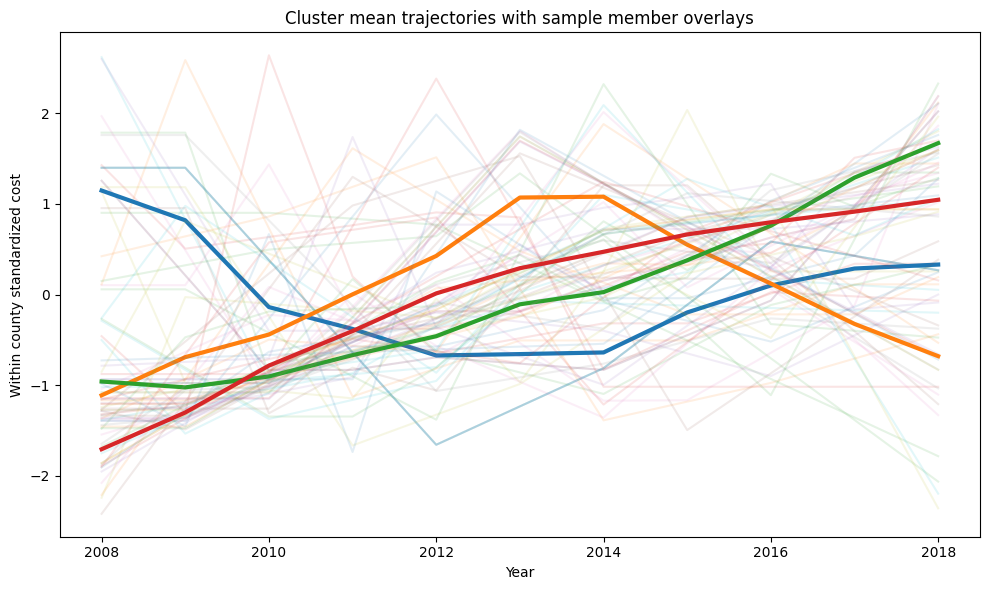

In [191]:
plt.figure(figsize=(10,6))

for c in range(K_FINAL):
    members = traj_z.loc[clustered.index[clustered["cluster"] == c]]
    mean_line = members.mean(axis=0)

    overlay = members.sample(n=min(20, len(members)), random_state=0)
    for _, row in overlay.iterrows():
        plt.plot(years, row.values, alpha=0.12)

    plt.plot(years, mean_line.values, linewidth=3)

plt.title("Cluster mean trajectories with sample member overlays")
plt.xlabel("Year")
plt.ylabel("Within county standardized cost")
plt.tight_layout()
plt.show()

The cluster average trajectories show clearly distinct growth shapes including gradual steady increases faster late period growth and more uneven or partially flat patterns. The overlaid individual trajectories suggest that while there is within cluster variability the average lines capture meaningful common structure.

## 5.Method 2 PCA

PCA provides a simple second unsupervised view of trajectory structure. If clusters reflect real variation, we should see some separation in a low dimensional projection.


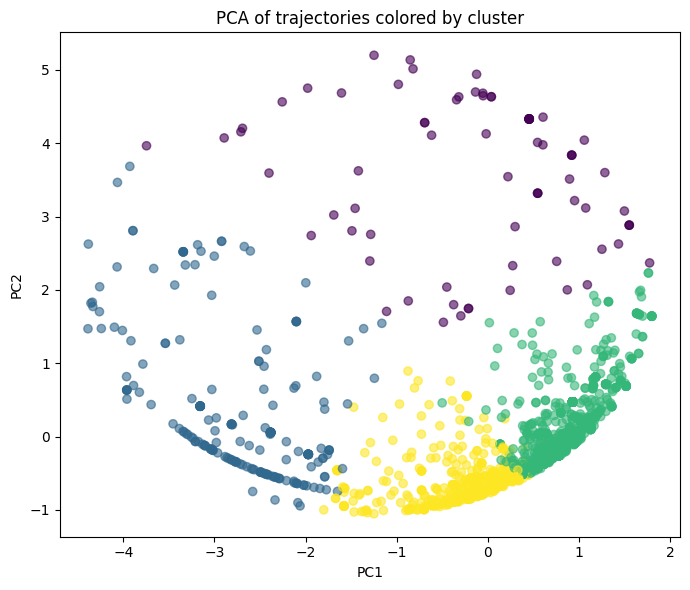

Explained variance ratio: [0.375 0.257]


In [192]:
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=labels, alpha=0.6)
plt.title("PCA of trajectories colored by cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

The PCA projection shows visible structure in the trajectory data, with counties forming broad groups. Points with the same cluster label tend to occupy similar regions of the low dimensional space, although there is still overlap between clusters. The clusters are not perfectly separated, which matches the moderate silhouette values. The first two principal components explain a meaningful share of the total variation, suggesting that a large part of the trajectory differences can be summarized in a low dimensional representation.


## 6.Who experiences each trajectory type



I link cluster membership to a small set of county context variables and state differences. This is descriptive association and not causal inference.

In [193]:
ctx_cols = [COUNTY_NAME, STATE_ABBR] + ["mhi_2018"]
ctx = (df[[COL_FIPS] + ctx_cols].drop_duplicates(subset=[COL_FIPS]).set_index(COL_FIPS))

who = clustered.join(ctx, how="left")
who.head()

,cluster,county_name,state_abbreviation,mhi_2018
county_fips_code,,,,
1001,2,Autauga County,AL,58462.55
1003,2,Baldwin County,AL,58219.90
1005,3,Barbour County,AL,37385.35
1007,3,Bibb County,AL,50464.30
1009,2,Blount County,AL,53048.35


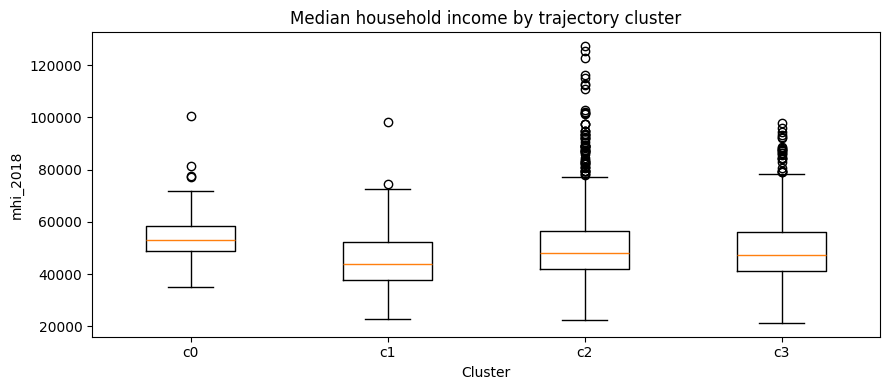

In [196]:
data = [who.loc[who["cluster"] == c, "mhi_2018"].dropna() for c in range(K_FINAL)]
plt.figure(figsize=(9,4))
plt.boxplot(data, tick_labels=[f"c{c}" for c in range(K_FINAL)])
plt.title("Median household income by trajectory cluster")
plt.xlabel("Cluster")
plt.ylabel("mhi_2018")
plt.tight_layout()
plt.show()

Median household income differs across trajectory clusters, although the distributions overlap substantially. Some clusters tend to have higher typical income levels, while others are centered at lower income ranges, suggesting that growth patterns in childcare costs are not evenly experienced across socioeconomic contexts. At the same time, the wide spreads and many outliers indicate considerable within-cluster heterogeneity. This suggests that income alone does not determine trajectory type, but it may be one factor associated with which childcare cost growth patterns counties experience.


## 7.Conclusion

1) Dead ends

I considered clustering percent change trajectories to focus purely on growth rates. In practice the representation was fragile because percent change amplifies small gaps and year to year noise, and it reduced interpretability compared with standardized level trajectories. Because the goal here is interpretable recurring shapes, I kept standardized level trajectories as the main representation.

2) Key takeaways

First, the clustering suggests counties follow a small number of recurring growth shapes rather than completely unique paths  
Second, trajectory types show descriptive differences across socioeconomic context, which matters for anticipating where affordability pressures may rise faster

3) Summary

Coverage thresholds matter because sparse reporting can dominate apparent patterns. Standardizing within county helped isolate trajectory shape from cost level. Metrics do not point to a single perfect k, so interpretability and stability across checks matter alongside silhouette.

4) Next steps

I will test robustness by trying a few coverage thresholds and checking whether cluster mean shapes remain similar. I also plan to extend the trajectory representation to jointly include infant toddler and preschool costs and evaluate whether the same counties remain grouped together when considering all age groups.

